# PRIOR GUIDED MODEL


In [16]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Results directory ──
RESULTS_DIR = (
    '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/prior_guided_grid_search_metric-euclidean_nmc1_task2'
)

#/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/3step_grid_search_metric-cosine_t5_nmc1_task0/
# ── Load merged grid search results ──
grid = np.load(os.path.join(RESULTS_DIR, 'grid_search_results_prior_guided.npz'))
sigma0_grid = grid['sigma0_grid']
sigma_grid = grid['sigma_grid']
eta_grid = grid['eta_grid']
ISI_VALUES = tuple(grid['isi_values'].astype(int))

# 3D d' arrays: results[isi][i_s0, i_s1, i_s2]
results = {isi: grid[f'dprime_isi{isi}'] for isi in ISI_VALUES}

# ── Flatten into DataFrame ──
rows = []
for i0, s0 in enumerate(sigma0_grid):
    for i1, s1 in enumerate(sigma_grid):
        for i2, s2 in enumerate(eta_grid):
            row = {'sigma0': s0, 'sigma': s1, 'eta': s2,
                   'i_s0': i0, 'i_s1': i1, 'i_s2': i2}
            for isi in ISI_VALUES:
                row[f'dprime_isi{isi}'] = results[isi][i0, i1, i2]
            rows.append(row)

df = pd.DataFrame(rows)
print(f'Total grid points: {len(df)}')
print(f'Grid: {len(sigma0_grid)} x {len(sigma_grid)} x {len(eta_grid)}')
print(f'ISI values: {ISI_VALUES}')
print(f'sigma0: {sigma0_grid}')
print(f'sigma: {sigma_grid}')
print(f'eta: {eta_grid}')

Total grid points: 3375
Grid: 15 x 15 x 15
ISI values: (0, 1, 2, 4, 8, 16, 32, 64)
sigma0: [0.00000000e+00 1.00000000e-02 1.82549228e-02 3.33242206e-02
 6.08331075e-02 1.11050368e-01 2.02721590e-01 3.70066697e-01
 6.75553899e-01 1.23321843e+00 2.25123072e+00 4.10960430e+00
 7.50205092e+00 1.36949360e+01 2.50000000e+01]
sigma: [ 0.          0.01        0.01701254  0.02894266  0.04923883  0.08376776
  0.14251027  0.2424462   0.41246264  0.70170383  1.19377664  2.03091762
  3.45510729  5.87801607 10.        ]
eta: [0.         0.001      0.00170125 0.00289427 0.00492388 0.00837678
 0.01425103 0.02424462 0.04124626 0.07017038 0.11937766 0.20309176
 0.34551073 0.58780161 1.        ]


In [17]:
# ── Load human d' curve ──
from utls.runners_utils import load_experiment_data, compute_human_curve

which_task = 2   # first multi-ISI task
is_multi = True

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi=None, is_multi=is_multi)
)

# Human curve ISIs for is_multi: [0, 1, 2, 4, 8, 16, 32, 64]
human_isis_full = np.array([0, 1, 2, 4, 8, 16, 32, 64])
human_curve_full = compute_human_curve(human_runs, is_multi, which_isi=None)

# Grid ISIs (from npz) may not include ISI=3 — align to grid
grid_isis = np.array(ISI_VALUES)
mask = np.isin(human_isis_full, grid_isis)
human_dp = human_curve_full[mask]
isis = human_isis_full[mask]

assert len(human_dp) == len(grid_isis), (
    f'Mismatch: human has {len(human_dp)} ISIs, grid has {len(grid_isis)}'
)

print(f'Task: {hr_task_name} ({task_name})')
print(f'Human participants: {len(human_runs)}')
print(f'Aligned ISIs: {isis}')
print(f'Human d\': {np.round(human_dp, 3)}')

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


Task: Auditory Textures (atexts)
Human participants: 120
Aligned ISIs: [ 0  1  2  4  8 16 32 64]
Human d': [2.164 1.831 1.322 1.203 1.071 1.006 0.968 0.877]


In [20]:
# ── Filter: sigma0 >= sigma >= eta ──
df_filt = df.copy()

# ── Classify model types: Based on eta and diffusion (sigma) values ──
def classify(row):
    s0, s = row['sigma0'], row['sigma']
    eta = row['eta']
    # If eta == 0, it's purely diffusive (random walk, no drift)
    if eta == 0:
        return 'purely diffusive'
    # If all diffusive components are zero, it's a pure attractor (drift-only)
    elif s == 0:
        return 'attractor'
    # Otherwise, it's a prior drift + diffusion process
    else:
        return 'prior drift diffusion'

df_filt['model_class'] = df_filt.apply(classify, axis=1)
print('\nModel class counts:')
print(df_filt['model_class'].value_counts().to_string())


Model class counts:
model_class
prior drift diffusion    2940
purely diffusive          225
attractor                 210


In [21]:
# ── Compute MSE to human curve ──
dp_cols = [f'dprime_isi{isi}' for isi in grid_isis]
model_dp_matrix = df_filt[dp_cols].values  # (n_models, n_isis)

# MSE per model (ignoring NaN entries)
diff = model_dp_matrix - human_dp[np.newaxis, :]
mse = np.nanmean(diff**2, axis=1)
df_filt['mse'] = mse

# Drop rows that are all NaN
df_filt = df_filt.dropna(subset=['mse'])
print(f'Models with valid MSE: {len(df_filt)}')
print(f'MSE range: {df_filt["mse"].min():.4f} – {df_filt["mse"].max():.4f}')

Models with valid MSE: 1949
MSE range: 0.1552 – 29.5265


/tmp/ipykernel_1481749/4011528738.py:7: RuntimeWarning: Mean of empty slice
  mse = np.nanmean(diff**2, axis=1)


In [22]:
# ── Best models per class ──
N_BEST = 15
CLASS_ORDER = ['prior drift diffusion', 'purely diffusive', 'attractor']

best_per_class = {}
for cls in CLASS_ORDER:
    sub = df_filt[df_filt['model_class'] == cls].nsmallest(N_BEST, 'mse')
    best_per_class[cls] = sub
    if len(sub) == 0:
        print(f'\n=== {cls}: no models ===')
        continue
    print(f'\n=== {cls} (n={len(df_filt[df_filt["model_class"]==cls])}) — top {len(sub)} by MSE ===')
    display_cols = ['sigma0', 'sigma', 'eta', 'mse']
    print(sub[display_cols].to_string(index=False, float_format='{:.4f}'.format))


=== prior drift diffusion (n=1693) — top 15 by MSE ===
 sigma0  sigma    eta    mse
 0.6756 0.0289 0.0412 0.1552
 0.6756 0.0170 0.0242 0.1587
 0.6756 0.0289 0.0702 0.1719
 0.6756 0.0170 0.0412 0.1856
 0.6756 0.0289 0.0242 0.1888
 0.6756 0.0170 0.0143 0.1906
 0.6756 0.0289 0.0143 0.2167
 0.6756 0.0100 0.0143 0.2194
 0.6756 0.0492 0.0702 0.2204
 0.6756 0.0100 0.0242 0.2244
 0.6756 0.0170 0.0084 0.2246
 0.6756 0.0492 0.1194 0.2271
 0.6756 0.0289 0.0084 0.2318
 0.6756 0.0289 0.0049 0.2398
 0.6756 0.0170 0.0702 0.2407

=== purely diffusive (n=130) — top 15 by MSE ===
 sigma0  sigma    eta    mse
 0.6756 0.0289 0.0000 0.2533
 0.6756 0.0170 0.0000 0.2655
 0.6756 0.0492 0.0000 0.2875
 0.6756 0.0100 0.0000 0.3140
 0.6756 0.0000 0.0000 0.3760
 0.6756 0.0838 0.0000 0.4008
 0.3701 0.0838 0.0000 0.5451
 0.2027 0.1425 0.0000 0.6992
 0.0100 0.1425 0.0000 0.6995
 0.0183 0.1425 0.0000 0.6995
 0.0333 0.1425 0.0000 0.6997
 0.0000 0.1425 0.0000 0.6997
 0.1111 0.1425 0.0000 0.7001
 0.0608 0.1425 0.0000 0.

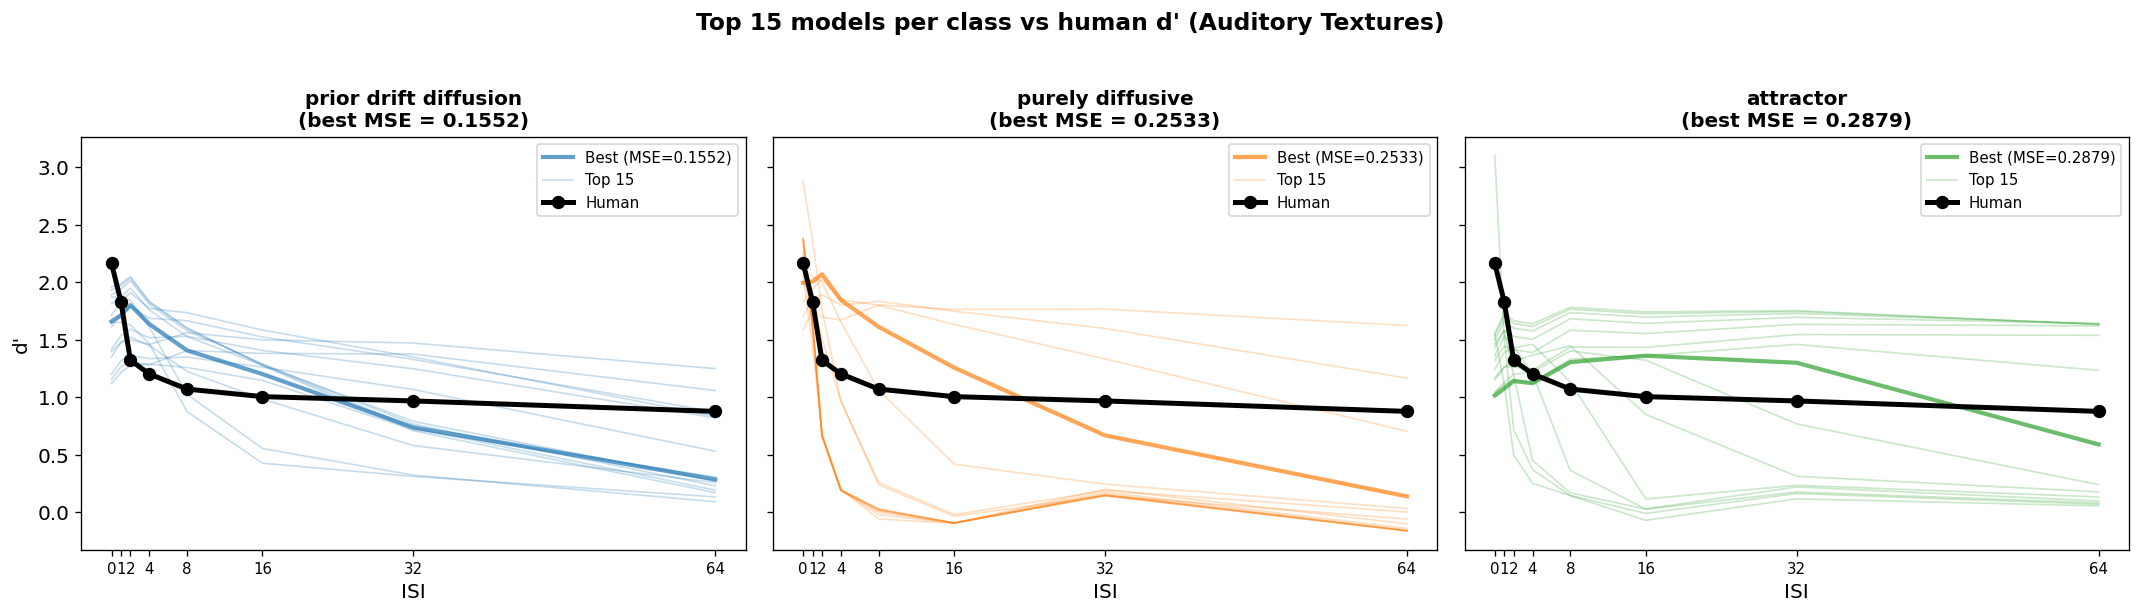

In [23]:
# ── Plot: best models per class vs human curve ──
CLASS_COLORS = {
    'prior drift diffusion': 'tab:blue',
    'purely diffusive': 'tab:orange',
    'attractor': 'tab:green'
}

# Use ISI values themselves for x-coordinates for correct spacing
x = np.array(grid_isis)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, cls in zip(axes, CLASS_ORDER):
    sub = best_per_class[cls]
    color = CLASS_COLORS[cls]

    # Plot each model curve
    for i, (_, row) in enumerate(sub.iterrows()):
        model_curve = row[dp_cols].values.astype(float)
        alpha = 0.7 if i == 0 else 0.25
        lw = 2.5 if i == 0 else 1.0
        label = f'Best (MSE={row["mse"]:.4f})' if i == 0 else (f'Top {N_BEST}' if i == 1 else None)
        ax.plot(x, model_curve, '-', color=color, alpha=alpha, linewidth=lw, label=label)

    # Human curve
    ax.plot(x, human_dp, 'o-k', linewidth=3, markersize=7, label='Human', zorder=10)

    ax.set_xticks(x)
    ax.set_xticklabels(grid_isis, fontsize=9)
    ax.set_xlabel('ISI', fontsize=12)
    if ax == axes[0]:
        ax.set_ylabel("d'", fontsize=12)
    ax.set_title(f'{cls}\n(best MSE = {sub["mse"].min():.4f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle(f"Top {N_BEST} models per class vs human d' ({hr_task_name})",
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

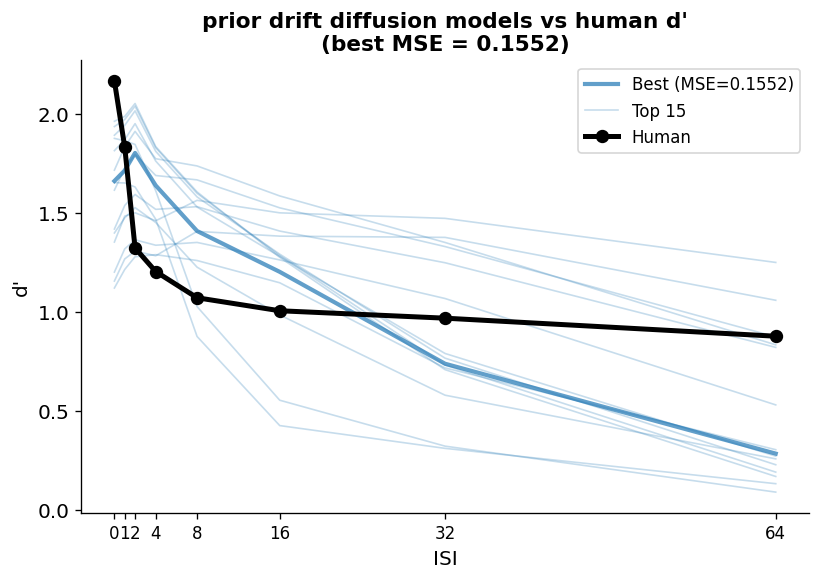

In [24]:
# ── Plot: 3-step regime models vs human curve ──

fig, ax = plt.subplots(figsize=(7, 5))
# Use ISI values themselves for x-coordinates for correct spacing
x = np.array(grid_isis)
cls = 'prior drift diffusion'
sub = best_per_class[cls]
color = CLASS_COLORS[cls]

# Plot each model curve
for i, (_, row) in enumerate(sub.iterrows()):
    model_curve = row[dp_cols].values.astype(float)
    alpha = 0.7 if i == 0 else 0.25
    lw = 2.5 if i == 0 else 1.0
    label = f'Best (MSE={row["mse"]:.4f})' if i == 0 else (f'Top {N_BEST}' if i == 1 else None)
    ax.plot(x, model_curve, '-', color=color, alpha=alpha, linewidth=lw, label=label)

# Human curve
ax.plot(x, human_dp, 'o-k', linewidth=3, markersize=7, label='Human', zorder=10)

ax.set_xticks(x)
ax.set_xticklabels(grid_isis, fontsize=10)
ax.set_xlabel('ISI', fontsize=12)
ax.set_ylabel("d'", fontsize=12)
ax.set_title(f"prior drift diffusion models vs human d'\n(best MSE = {sub['mse'].min():.4f})", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()

          Model class  N models  Best MSE  Mean top-15 MSE  Best σ₀   Best σ   Best η
prior drift diffusion      1693  0.155219         0.206389 0.675554 0.028943 0.041246
     purely diffusive       130  0.253259         0.536273 0.675554 0.028943 0.000000
            attractor       126  0.287926         0.394240 0.675554 0.000000 0.041246


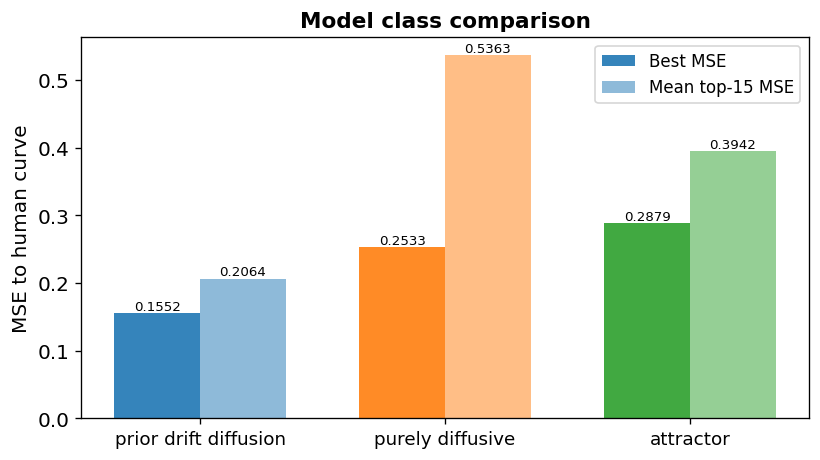

In [25]:
# ── Summary: MSE comparison across classes ──
summary_rows = []
for cls in CLASS_ORDER:
    sub = best_per_class[cls]
    n_total = len(df_filt[df_filt['model_class'] == cls])
    if len(sub) == 0:
        continue
    best_row = sub.iloc[0]
    summary_rows.append({
        'Model class': cls,
        'N models': n_total,
        'Best MSE': sub['mse'].min(),
        f'Mean top-{N_BEST} MSE': sub['mse'].mean(),
        'Best σ₀': best_row['sigma0'],
        'Best σ': best_row['sigma'],
        'Best η': best_row['eta'],
    })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

# ── Bar plot ──
fig, ax = plt.subplots(figsize=(7, 4))
classes = summary['Model class']
x = np.arange(len(classes))
width = 0.35

bars1 = ax.bar(x - width/2, summary['Best MSE'], width,
               label='Best MSE', color=[CLASS_COLORS[c] for c in classes], alpha=0.9)
bars2 = ax.bar(x + width/2, summary[f'Mean top-{N_BEST} MSE'], width,
               label=f'Mean top-{N_BEST} MSE', color=[CLASS_COLORS[c] for c in classes], alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylabel('MSE to human curve', fontsize=12)
ax.set_title('Model class comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Add value labels
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.4f}',
            ha='center', va='bottom', fontsize=8)

fig.tight_layout()
plt.show()

In [26]:
# # ── Store best parameters for downstream use ──
# print('\nBest parameters per class:')
# for cls in CLASS_ORDER:
#     sub = best_per_class[cls]
#     if len(sub) == 0:
#         continue
#     best = sub.iloc[0]
#     print(f'  {cls}: σ₀={best["sigma0"]:.4f}, σ={best["sigma"]:.4f}, '
#           f'η={best["eta"]:.4f}  (MSE={# ── Store best parameters for downstream use ──
# print('\nBest parameters per class:')
# for cls in CLASS_ORDER:
#     sub = best_per_class[cls]
#     if len(sub) == 0:
#         continue
#     best = sub.iloc[0]
#     print(f'  {cls}: σ₀={best["sigma0"]:.4f}, σ={best["sigma"]:.4f}, '
#           f'η={best["eta"]:.4f}  (MSE={best["mse"]:.4f})'):.4f})')

In [27]:
target_isi = 2
exp_list_single, all_files_single, name_to_idx_single, human_runs_single, task_name_single, hr_task_name_single = (
    load_experiment_data(which_task, which_isi=2, is_multi=False)
)

print(name_to_idx_single)

{'/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/sequences/mem_stim_0.wav': 0, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/sequences/mem_stim_1.wav': 1, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/sequences/mem_stim_10.wav': 2, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/sequences/mem_stim_11.wav': 3, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/sequences/mem_stim_12.wav': 4, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/sequences/mem_stim_13.wav': 5, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/sequences/mem_stim_14.wav': 6, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atex

In [28]:
# Human curve ISIs for is_multi: [0, 1, 2, 4, 8, 16, 32, 64]
human_isis_full_single = np.array([0, 16])
human_curve_full_single = compute_human_curve(human_runs_single, False, which_isi=16)
print(human_curve_full_single)

[2.17840344]


/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


In [29]:
# ── Find the best class (lowest mean MSE), and top 15 best parameters from its models ──

# Determine best class by mean MSE
class_mse_means = {}
for cls in CLASS_ORDER:
    sub = best_per_class[cls]
    if len(sub) == 0: continue
    class_mse_means[cls] = sub['mse'].mean()
if len(class_mse_means) == 0:
    print("No best parameters found across classes.")
else:
    best_class = min(class_mse_means, key=class_mse_means.get)
    print(f"\nBest class by mean MSE: {best_class}")

    # Select top 15 models of best class by lowest MSE
    best_class_df = best_per_class[best_class].sort_values('mse')
    top15 = best_class_df.head(15)
    param_names = ["sigma0", "sigma", "eta"]
    top15_params = [[row["sigma0"], row["sigma"], row["eta"]] for _, row in top15.iterrows()]

    print("\nTop 15 parameter sets from best class:")
    for i, row in top15.iterrows():
        print(f'  {best_class}: σ₀={row["sigma0"]:.4f}, σ={row["sigma"]:.4f}, '
              f'η={row["eta"]:.4f}  (MSE={row["mse"]:.4f})')

    print("\nList of parameter lists (for refined grid search):")
    print(top15_params)


Best class by mean MSE: prior drift diffusion

Top 15 parameter sets from best class:
  prior drift diffusion: σ₀=0.6756, σ=0.0289, η=0.0412  (MSE=0.1552)
  prior drift diffusion: σ₀=0.6756, σ=0.0170, η=0.0242  (MSE=0.1587)
  prior drift diffusion: σ₀=0.6756, σ=0.0289, η=0.0702  (MSE=0.1719)
  prior drift diffusion: σ₀=0.6756, σ=0.0170, η=0.0412  (MSE=0.1856)
  prior drift diffusion: σ₀=0.6756, σ=0.0289, η=0.0242  (MSE=0.1888)
  prior drift diffusion: σ₀=0.6756, σ=0.0170, η=0.0143  (MSE=0.1906)
  prior drift diffusion: σ₀=0.6756, σ=0.0289, η=0.0143  (MSE=0.2167)
  prior drift diffusion: σ₀=0.6756, σ=0.0100, η=0.0143  (MSE=0.2194)
  prior drift diffusion: σ₀=0.6756, σ=0.0492, η=0.0702  (MSE=0.2204)
  prior drift diffusion: σ₀=0.6756, σ=0.0100, η=0.0242  (MSE=0.2244)
  prior drift diffusion: σ₀=0.6756, σ=0.0170, η=0.0084  (MSE=0.2246)
  prior drift diffusion: σ₀=0.6756, σ=0.0492, η=0.1194  (MSE=0.2271)
  prior drift diffusion: σ₀=0.6756, σ=0.0289, η=0.0084  (MSE=0.2318)
  prior drift di

In [30]:
print(len(top15_params))

15


In [35]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

import types
import sys

# Mock 'cox' and 'cox.store' so constants.py doesn't crash
cox_mock = types.ModuleType('cox')
store_mock = types.ModuleType('cox.store')
store_mock.PYTORCH_STATE = 'pytorch_state'  # the only attr actually used
cox_mock.store = store_mock
sys.modules['cox'] = cox_mock
sys.modules['cox.store'] = store_mock


# project paths
sys.path.insert(0, os.path.abspath('..'))
sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/')

import torch

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set

from utls.encoders import *
from utls.runners_v2 import run_model_core, make_noise_schedule
from utls.runners_utils import load_experiment_data, build_encoder, encode_stimuli
from utls.toy_experiments import make_high_diversity_sequences
from utls.roc_utils import roc_from_arrays
from utls.analysis_helpers import auroc_to_dprime
from src.model.ScoreFunction import ScoreFunction

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})
print('Imports OK')

Imports OK


/orcd/data/jhm/001/om2/lakshmin/audio-prior/utils/sde_utils.py:10: SyntaxWarning: invalid escape sequence '\s'
  """Compute the mean and standard deviation of $p_{0t}(x(t) | x(0))$.
/orcd/data/jhm/001/om2/lakshmin/audio-prior/utils/sde_utils.py:24: SyntaxWarning: invalid escape sequence '\s'
  """Compute the diffusion coefficient of our SDE.


In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"
encoder_cfg = dict(
    encoder_type='texture_pca',
    model_name='texture_pca',
    statistics_dict=statistics_set.statistics,
    model_params=model_params,
    pc_dims=256,
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    device=device,
)

pc_dims = 256



pc_texture_model = AudioTextureEncoderPCA(
    statistics_dict=statistics_set.statistics,
    pc_dims=pc_dims,
    model_params=model_params,
    sr=20000,
    rms_level=0.01,
    duration=2.0,
    device=device
)

print(f'Building prior encoder...')

encoder = pc_texture_model


print(f'Encoding {len(all_files)} stimuli ...')
X0 = encode_stimuli(encoder, all_files)
print(f'X0 shape: {X0.shape}')
print(f'Any NaN: {torch.isnan(X0).any().item()}')

score_config = '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/assets/bryan.yaml'
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Loading score model from {score_config} ...')
score_model = ScoreFunction(
    mode='textures',
    restart=True,
    config=score_config,
    device=device,
    normalize=True,
)
print('Score model loaded.')



Building prior encoder...
Encoding 80 stimuli ...
X0 shape: torch.Size([80, 256])
Any NaN: False
Loading score model from /orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/assets/bryan.yaml ...
Score model loaded.


In [14]:
ISI_VALUES = [0, 1, 2, 4, 8, 16, 32, 64]
N_SEQUENCES = 300
SEQ_LENGTH = 135

stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f'Stimulus pool: {len(stimulus_pool)} unique stimuli')

experiment_list, isi_keys = make_high_diversity_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=ISI_VALUES,
    n_sequences=N_SEQUENCES,
    length=SEQ_LENGTH,
    min_pairs_per_isi=4,
    seed=420483,
)

print(f'{len(experiment_list)} sequences, {len(experiment_list[0])} trials each')

Aggregate ISI usage across all sequences:
  ISI -1: 13500
  ISI 0: 3544
  ISI 1: 3018
  ISI 2: 3202
  ISI 4: 3202
  ISI 8: 3566
  ISI 16: 3540
  ISI 32: 3460
  ISI 64: 3468
300 sequences, 135 trials each


In [37]:
exp_list_single_no_seq = [
    [s.replace('/sequences/', '/') for s in seq]
    for seq in exp_list_single
]
exp_list_single_no_seq[0][0], experiment_list[0][0]

('/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/mem_stim_37.wav',
 '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/mem_stim_69.wav')

In [ ]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../src/model'))
from run_prior_guided_grid_search import run_mc_dprime

factor = 2.0
best_sigma0, best_sigma, best_eta = 0.6756*factor, 0.0289, 0.0412
t_step = 4
metric = "euclidean"

N_EXP_LIST = [300]
seed_base = 3010

dprime_curves_per_expnum = []
std_curves_per_expnum = []

t_start = time.perf_counter()

for i, nexps in enumerate(N_EXP_LIST):
    experiment_sublist = experiment_list[:nexps]
    print(f"\nRunning model on {nexps} experiments...")

    # one d' curve per experiment
    per_exp_curves = []

    for j, exp in enumerate(experiment_sublist):
        dp, _ = run_mc_dprime(
            best_sigma0,
            best_sigma,
            best_eta,
            X0=X0,
            name_to_idx=name_to_idx,
            experiment_list=[exp],   # exactly one experiment
            score_model=score_model,
            isi_values=tuple(ISI_VALUES),
            n_mc=1,                  # exactly one MC simulation
            seed=seed_base + i * 10000 + j,
            metric=metric,
        )
        
        exp_curve = []
        for isi in sorted(dp.keys()):
            #print(isi, dp[isi])
            exp_curve.append(dp[isi])
        per_exp_curves.append(np.asarray(exp_curve, dtype=float))

    per_exp_curves = np.vstack(per_exp_curves)   # shape: [nexps, n_isi]

    dprime_curves_per_expnum.append(np.nanmean(per_exp_curves, axis=0))
    std_curves_per_expnum.append(np.nanstd(per_exp_curves, axis=0))

elapsed = time.perf_counter() - t_start
print(f"\nCompleted all experiment number conditions in {elapsed:.1f}s")

dprime_curves_per_expnum = np.vstack(dprime_curves_per_expnum)
std_curves_per_expnum = np.vstack(std_curves_per_expnum)

plt.figure(figsize=(10, 6))
for i, nexps in enumerate(N_EXP_LIST):
    plt.plot(ISI_VALUES, dprime_curves_per_expnum[i], "-o", label=f"{nexps} experiments")
    plt.fill_between(
        ISI_VALUES,
        dprime_curves_per_expnum[i] - std_curves_per_expnum[i],
        dprime_curves_per_expnum[i] + std_curves_per_expnum[i],
        alpha=0.15,
    )

plt.xlabel("ISI")
plt.ylabel("d-prime")
plt.title("Average model d-prime vs ISI as number of experiments increases")
plt.legend()
plt.tight_layout()
plt.show()

df_curves_varying_exp = pd.DataFrame(
    dprime_curves_per_expnum,
    columns=[f"dprime_mean_isi{isi}" for isi in ISI_VALUES],
)
for idx, isi in enumerate(ISI_VALUES):
    df_curves_varying_exp[f"dprime_std_isi{isi}"] = std_curves_per_expnum[:, idx]
df_curves_varying_exp["n_experiments_used"] = N_EXP_LIST

df_curves_varying_exp



Running model on 300 experiments...


In [83]:
np.linspace(0.01, 1.0, 10)

array([0.01, 0.12, 0.23, 0.34, 0.45, 0.56, 0.67, 0.78, 0.89, 1.  ])

In [ ]:
# Stability analysis for a single hyperparameter set (fixed sigma0, sigma, eta) across many seeds

sys.path.insert(0, os.path.abspath('../src/model'))
from run_3step_grid_search import run_mc_dprime

# Choose ONE set of best-fit hyperparameters (these can be replaced with your favorite ones)
best_sigma0, best_sigma, best_eta = 13.694936, 2.251231, 0.375554

t_step = 4
metric = 'cosine'
N_repeats = 100  # Number of repeats (seeds) — increase as needed for desired stability analysis
n_mc_grid = 1    # Leave as 1 (one MC per experiment run) — or adjust as needed

rows = []
t_start = time.perf_counter()

print(f"Running stability for sigma0={best_sigma0:.6f}, sigma={best_sigma:.6f}, eta={best_eta:.6f}")
print(f"{N_repeats} repeats with different random seeds...")
for seed in range(N_repeats):
    dp, _ = run_mc_dprime(
        best_sigma0,
        best_sigma,
        best_eta,
        X0=X0,
        name_to_idx=name_to_idx,
        experiment_list=experiment_list[:15],
        t_step=t_step,
        isi_values=tuple(ISI_VALUES),
        n_mc=n_mc_grid,
        seed=seed,
        metric=metric,
    )
    row = {
        'seed': seed,
        'sigma0': best_sigma0,
        'sigma': best_sigma,
        'eta': best_eta,
    }
    for isi in ISI_VALUES:
        row[f'dprime_isi{isi}'] = dp.get(isi, np.nan)
    rows.append(row)

elapsed = time.perf_counter() - t_start
df_stability = pd.DataFrame(rows)
print(f'\nDone in {elapsed:.1f}s ({elapsed/N_repeats:.2f}s per run)')
df_stability

Running stability for sigma0=13.694936, sigma=2.251231, eta=0.375554
100 repeats with different random seeds...


KeyboardInterrupt: 

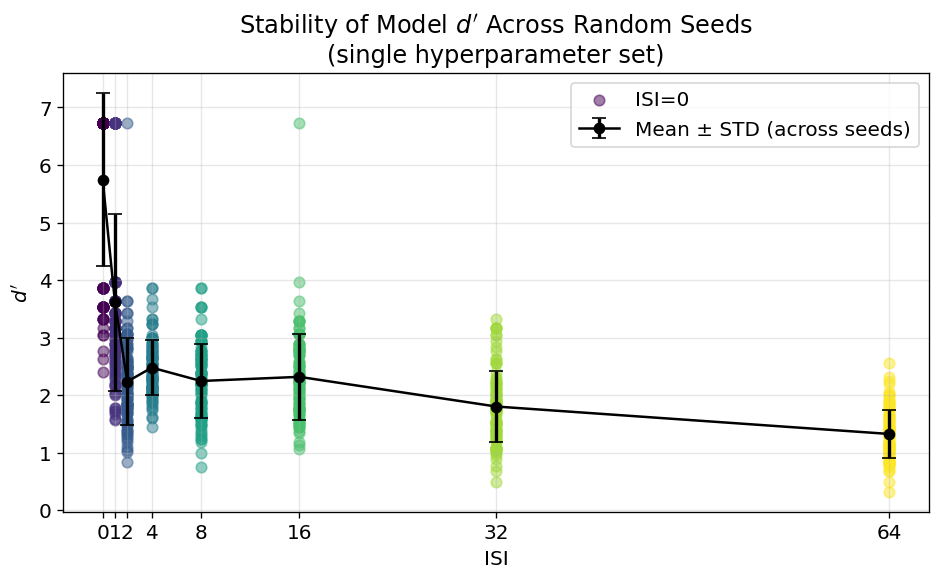

In [27]:
import matplotlib.pyplot as plt

# Plot stability analysis for the chosen hyperparameters (d' by ISI for all seeds)
plt.figure(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(ISI_VALUES)))
for idx, isi in enumerate(ISI_VALUES):
    isi_col = f'dprime_isi{isi}'
    if isi_col in df_stability.columns:
        plt.scatter(
            [isi] * len(df_stability),
            df_stability[isi_col],
            color=colors[idx],
            alpha=0.5,
            s=40,
            label=f'ISI={isi}' if idx == 0 else None
        )

# Optionally, overlay mean and std for each ISI
means = [df_stability[f'dprime_isi{isi}'].mean() for isi in ISI_VALUES]
stds = [df_stability[f'dprime_isi{isi}'].std() for isi in ISI_VALUES]
plt.errorbar(
    ISI_VALUES,
    means,
    yerr=stds,
    fmt='-o',
    color='black',
    ecolor='black',
    elinewidth=2,
    capsize=4,
    label="Mean ± STD (across seeds)"
)

plt.title("Stability of Model $d'$ Across Random Seeds\n(single hyperparameter set)")
plt.xlabel("ISI")
plt.ylabel("$d'$")
plt.grid(alpha=0.3)
plt.xticks(ISI_VALUES)
plt.legend()
plt.tight_layout()
plt.show()

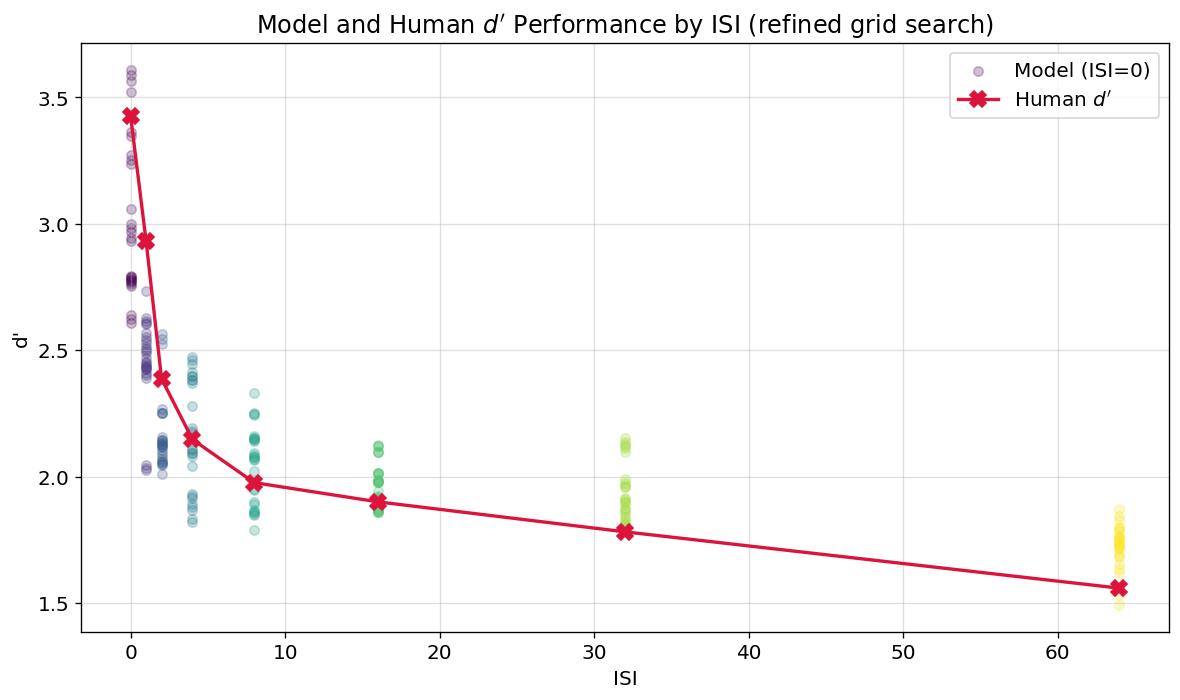

In [78]:
import matplotlib.pyplot as plt

# Plot all model dprime performance for each ISI (all grid search results)
plt.figure(figsize=(10, 6))
markers = ['o', '^', 's', 'd', 'p', '*', 'v', '<', '>']
colors = plt.cm.viridis(np.linspace(0, 1, len(ISI_VALUES)))
for idx, isi in enumerate(ISI_VALUES):
    isi_col = f'dprime_isi{isi}'
    if isi_col in df.columns:
        plt.scatter(
            [isi] * len(df),
            df[isi_col], 
            s=32, alpha=0.25, 
            color=colors[idx], 
            label=f'Model (ISI={isi})' if idx == 0 else None)

# Overlay: human performance (use human_dp list)
plt.plot(
    list(ISI_VALUES),
    list(human_dp),
    marker='X', markersize=10, color='crimson', linewidth=2,
    label="Human $d'$"
)

plt.xlabel('ISI')
plt.ylabel("d'")
plt.title("Model and Human $d'$ Performance by ISI (refined grid search)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## SINGLE ISI PERFORMANCE
# Import run_mc_dprime from the grid search script
sys.path.insert(0, os.path.abspath('../src/model'))
from run_3step_grid_search import run_mc_dprime

# Assume you have a variable called 'best_params_list' that stores all the best triples found earlier
# e.g., best_params_list = [(sigma0_1, sigma_1, eta_1), (sigma0_2, sigma_2, eta_2), ...]
# If not, you need to collect these from your previous results.

# Convert best_params_list to numpy array for easier slicing
best_params_arr = np.array(top15_params)  # shape: (N, 3)

# Let's search around the best parameters (lowest MSE) using the summary variable

# Find best parameter row (lowest mse) in the summary DataFrame

  
best_sigma0, best_sigma, best_eta = 13.694936, 2.251231, 0.375554

# Define a small window/range around the best params (e.g., +/-10% or fixed width)
delta0 = 0.1 * best_sigma0
delta1 = 0.1 * best_sigma
delta2 = 0.05 * best_eta

sigma0_min, sigma0_max = best_sigma0 - delta0, best_sigma0 + delta0
sigma_min, sigma_max = best_sigma - delta1, best_sigma + delta1
eta_min, eta_max = best_eta - delta2, best_eta + delta2

print(f"Centering grid on MSE best: sigma0={best_sigma0:.3g}, sigma={best_sigma:.3g}, eta={best_eta:.3g}")

print("Refined bounds:")
print(f"sigma0: min={sigma0_min}, max={sigma0_max}")
print(f"sigma: min={sigma_min}, max={sigma_max}")
print(f"eta: min={eta_min}, max={eta_max}")

N_MCs_test = 3
# Make new grids within these refined bounds (you can adjust num points as needed)
sigma0_grid = np.linspace(sigma0_min, sigma0_max, 3)
sigma_grid = np.linspace(sigma_min, sigma_max, N_MCs_test)
eta_grid = np.linspace(eta_min, eta_max, N_MCs_test)
t_step = 4
metric = 'cosine'

n_mc_grid = 1  # keep small for testing
total = len(sigma0_grid) * len(sigma_grid) * len(eta_grid)
print(f'Running {total} triples (n_mc={n_mc_grid}) ...')

rows = []
t_start = time.perf_counter()

for i, s0 in enumerate(sigma0_grid):
    print(i)
    for s1 in sigma_grid:
        for s2 in eta_grid:
            dp, _ = run_mc_dprime(
                s0, s1, s2,
                X0=X0, name_to_idx=name_to_idx_single,
                experiment_list=exp_list_single[:10],
                t_step=t_step,
                isi_values=tuple(ISI_VALUES),
                n_mc=n_mc_grid,
                seed=42 + int(s0*1000 + s1*100 + s2*10),
                metric=metric,
            )
            row = {'sigma0': s0, 'sigma': s1, 'eta': s2}
            for isi in ISI_VALUES:
                row[f'dprime_isi{isi}'] = dp.get(isi, np.nan)
            rows.append(row)

elapsed = time.perf_counter() - t_start
df = pd.DataFrame(rows)
print(f'\nDone in {elapsed:.1f}s ({elapsed/total:.1f}s per triple)')
df